In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('expert_dataset.csv')
print(df.head)

<bound method NDFrame.head of               category      lat       lon  \
0      Known PFAS user  52.5041 -0.682637   
1      Known PFAS user  50.8719  6.034520   
2      Known PFAS user  50.2234  8.765600   
3      Known PFAS user  47.8586  5.347160   
4      Known PFAS user  39.4717 -0.538828   
...                ...      ...       ...   
44583            Known  51.2326  4.335670   
44584            Known  51.2302  4.337570   
44585            Known  51.3153  4.346180   
44586            Known  51.2343  4.334540   
44587            Known  51.2326  4.335070   

                                      name         city         country  \
0                                       3F        Corby  United Kingdom   
1                                       3M     Kerkrade     Netherlands   
2       3P - Performance Plastics Products       Karben         Germany   
3         3P Performance Plastics Products      Langres          France   
4      3P Productos Plásticos Performantes     Valenci

In [50]:
# Cleaning data 
df_clean = df.drop(columns=['source_type', 'source_url', 'details', ])

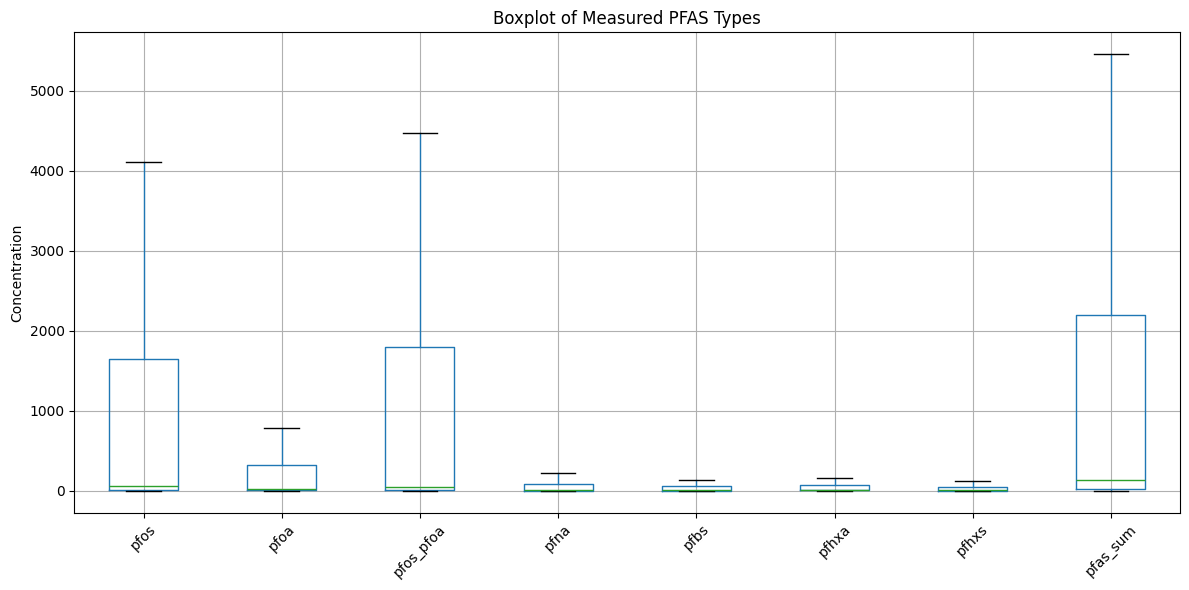

In [51]:
# Select only the columns of interest and drop rows where all are NaN
pfas_cols = ['pfos', 'pfoa', 'pfos_pfoa', 'pfna', 'pfbs', 'pfhxa', 'pfhxs', 'pfas_sum']
df_box = df[pfas_cols].dropna(how='all')

# Create a boxplot for the selected PFAS types
plt.figure(figsize=(12, 6))
df_box.boxplot(column=pfas_cols, showfliers=False)
plt.ylabel('Concentration')
plt.title('Boxplot of Measured PFAS Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

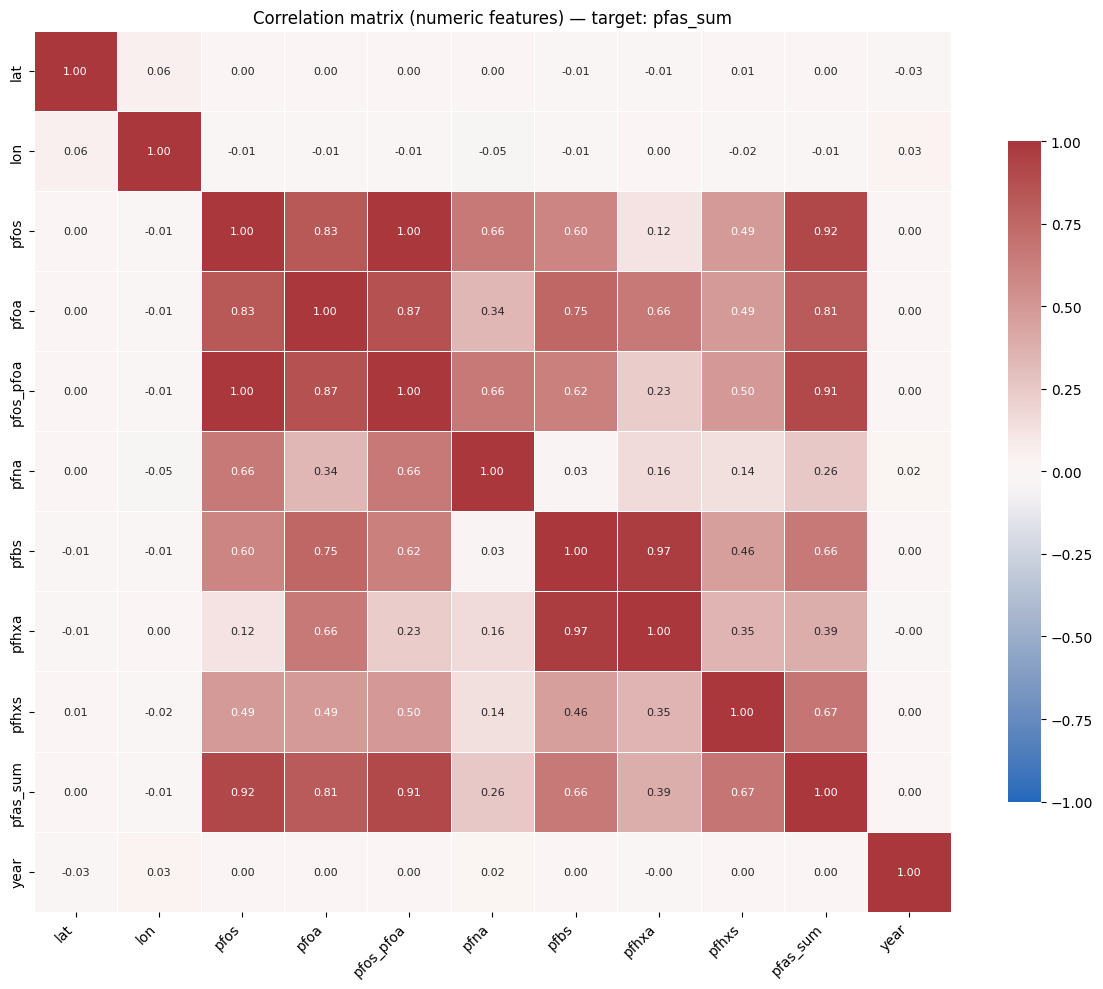

In [52]:
# show full correlation matrix (no mask), scale colors to [-1, 1] and reduce annot font
target = 'pfas_sum'

num_df = df.select_dtypes(include=[np.number]).copy()
if target not in num_df.columns:
    num_df[target] = pd.to_numeric(df[target], errors='coerce')

num_df = num_df.dropna(subset=[target])
corr = num_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt=".2f",
            linewidths=.5, vmin=-1, vmax=1, annot_kws={"size":8},
            cbar_kws={"shrink": .75})
plt.title(f"Correlation matrix (numeric features) — target: {target}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [53]:
# remove outliers above the 95th percentile for each PFAS column
for col in pfas_cols:
    threshold = df[col].quantile(0.95)
    df = df[df[col] <= threshold]

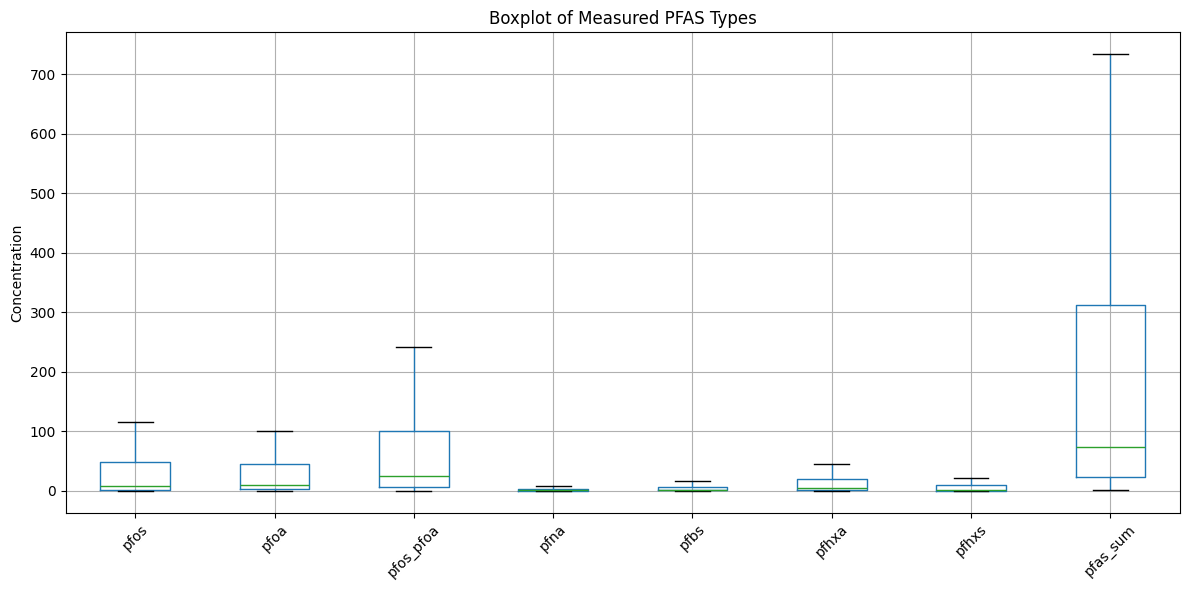

In [54]:
# Select only the columns of interest and drop rows where all are NaN
pfas_cols = ['pfos', 'pfoa', 'pfos_pfoa', 'pfna', 'pfbs', 'pfhxa', 'pfhxs', 'pfas_sum']
df_box = df[pfas_cols].dropna(how='all')

# Create a boxplot for the selected PFAS types
plt.figure(figsize=(12, 6))
df_box.boxplot(column=pfas_cols, showfliers=False)
plt.ylabel('Concentration')
plt.title('Boxplot of Measured PFAS Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
summary = df_box.describe().T  
print(summary)

            count        mean         std   min        25%    50%      75%  \
pfos       1047.0   71.958120  165.878375  0.00   1.600000   8.70   48.725   
pfoa       1047.0   52.859929  110.905307  0.00   2.630000  10.40   44.500   
pfos_pfoa  1047.0  124.818048  239.542014  0.00   5.904500  25.53  101.000   
pfna       1047.0   10.189017   30.015362  0.00   0.210000   0.96    3.000   
pfbs       1047.0    7.425655   15.877393  0.00   0.435000   1.80    6.650   
pfhxa      1047.0   24.930204   57.601630  0.00   1.207627   5.00   19.000   
pfhxs      1047.0   12.349127   28.383578  0.00   0.200000   1.64    9.000   
pfas_sum   1047.0  261.805505  391.790343  1.62  22.250000  73.20  312.600   

                   max  
pfos       1600.000000  
pfoa       1000.000000  
pfos_pfoa  2300.000000  
pfna        229.784095  
pfbs        170.000000  
pfhxa       640.000000  
pfhxs       200.000000  
pfas_sum   1791.033763  


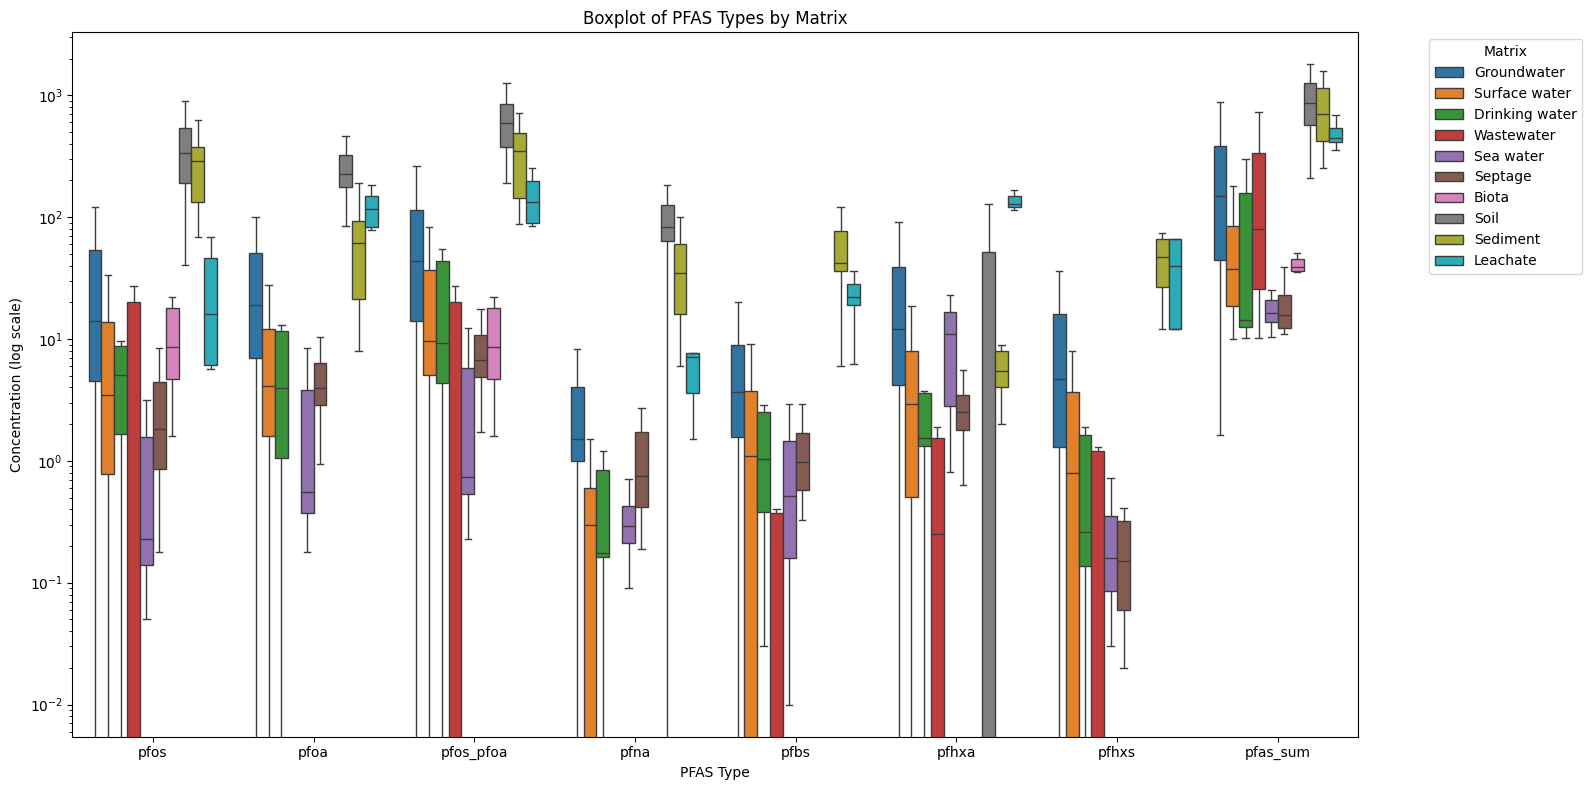

In [56]:
import seaborn as sns

# Create a boxplot for each PFAS type, grouped by unique 'matrix' values
plt.figure(figsize=(16, 8))
df_melt = df.melt(id_vars='matrix', value_vars=pfas_cols, var_name='PFAS Type', value_name='Concentration')
df_melt = df_melt.dropna(subset=['Concentration', 'matrix'])

sns.boxplot(data=df_melt, x='PFAS Type', y='Concentration', hue='matrix', showfliers=False)
plt.yscale('log')
plt.title('Boxplot of PFAS Types by Matrix')
plt.ylabel('Concentration (log scale)')
plt.xlabel('PFAS Type')
plt.legend(title='Matrix', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

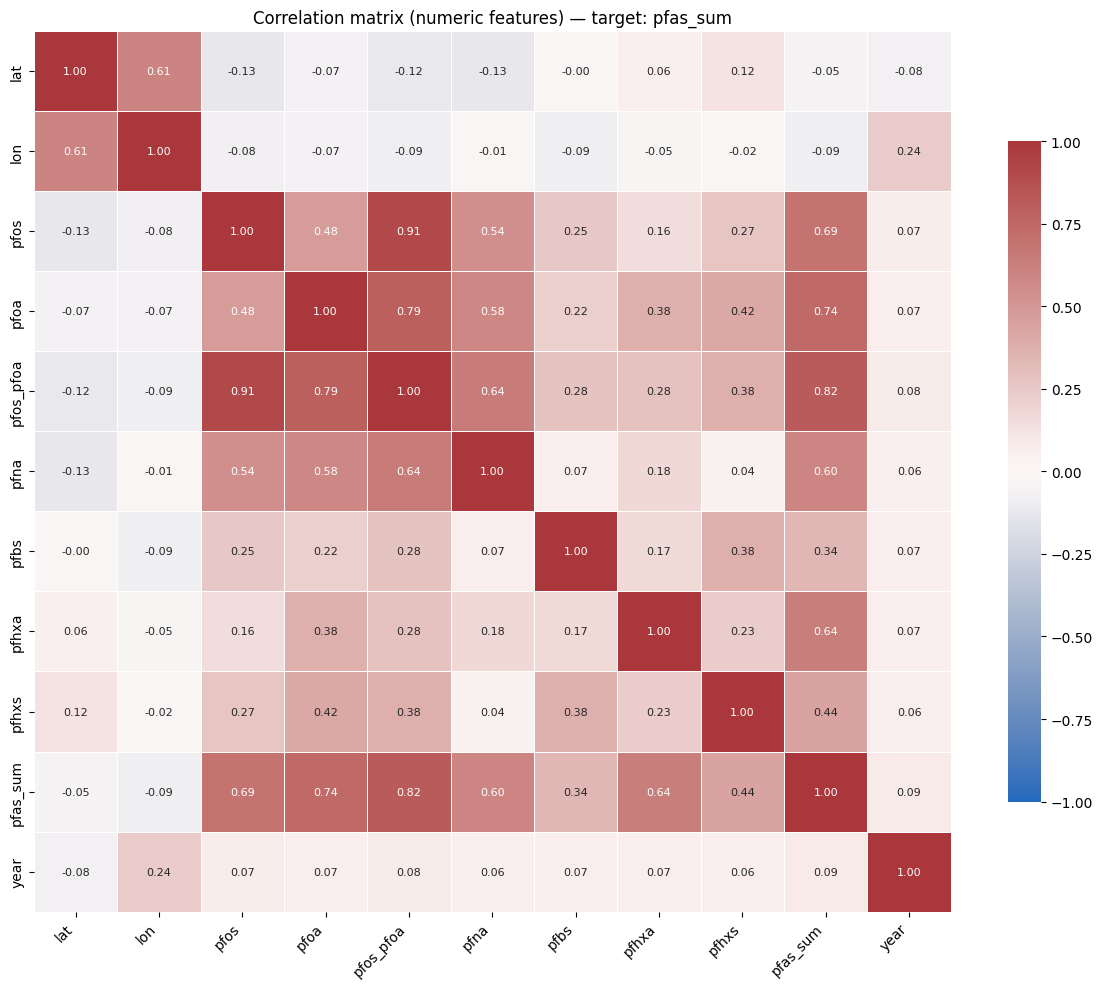

In [57]:
# show full correlation matrix (no mask), scale colors to [-1, 1] and reduce annot font
target = 'pfas_sum'

num_df = df.select_dtypes(include=[np.number]).copy()
if target not in num_df.columns:
    num_df[target] = pd.to_numeric(df[target], errors='coerce')

num_df = num_df.dropna(subset=[target])
corr = num_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt=".2f",
            linewidths=.5, vmin=-1, vmax=1, annot_kws={"size":8},
            cbar_kws={"shrink": .75})
plt.title(f"Correlation matrix (numeric features) — target: {target}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [68]:
# setting up the data
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd

# Columns to estimate
pfas_cols = ['pfas_sum']

# Choose matrix type
selected_matrix = "Groundwater"  
# Choose cordinate set
your_lat = 57.7381
your_lon = 10.5678

new_coords = np.array([[your_lat, your_lon]])

df_valid = df_clean[
    (df_clean['matrix'] == selected_matrix)
].dropna(subset=['lat', 'lon'] + pfas_cols, how='any')


X = df_valid[['lat', 'lon']].values

# Targets: multiple PFAS columns
y = df_valid[pfas_cols].values

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def split_data(X, y, test_size=0.2, random_state=42):
    """Splits features and targets (y should be log-transformed here)."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )
    return X_train, X_test, y_train, y_test

def calculate_evaluation_metrics(y_true, y_pred, target_names):
    """Calculates R2 by comparing RAW (untransformed) values."""
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape.")
    
    r2_scores = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    mean_concentrations = np.mean(y_true, axis=0)
    
    results_df = pd.DataFrame({
        'Target': target_names,
        'R2 Score': r2_scores,
        'Mean Concentration (y_true)': mean_concentrations
    })
    
    return results_df.set_index('Target')

def inverse_transform_predictions(y_pred_log):
    """Applies the inverse transformation: exp(x) - 1."""
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw[y_pred_raw < 0] = 0 
    return y_pred_raw

def transform_targets(y_raw):
    """Applies a log-transformation: log(1 + x)."""
    y_transformed = np.log1p(y_raw)
    return y_transformed.values

def calculate_evaluation_metrics(y_true, y_pred, target_names):
    """Calculates R2, MAE, and RMSE by comparing RAW values."""
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape.")
    
    r2_scores = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    maes = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    rmses = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(y_true.shape[1])]
    mean_concentrations = np.mean(y_true, axis=0)
    
    results_df = pd.DataFrame({
        'Target': target_names,
        'R2 Score': r2_scores,
        'MAE (Raw Scale)': maes,
        'RMSE (Raw Scale)': rmses,
        'Mean Concentration (y_true)': mean_concentrations
    })
    
    return results_df.set_index('Target')

In [70]:
X_train, X_test, y_train, y_test = split_data(X, y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# log-transform the target arrays
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [71]:
#Define and train KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn_model.fit(X_train_scaled, y_train_log)

y_pred_log_knn = knn_model.predict(X_test_scaled)


print("\nSTEP 3: Inverse Transform and Evaluate")

# INVERSE TRANSFORM predictions back to the original (raw) concentration scale
y_pred_raw_knn = inverse_transform_predictions(y_pred_log_knn)

y_test = inverse_transform_predictions(y_test_log)


# Calculate metrics: Compare y_test_raw (True values) vs y_pred_raw_knn (Predictions)
knn_evaluation_results = calculate_evaluation_metrics(y_test, y_pred_raw_knn, pfas_cols)

print("--- KNN EVALUATION RESULTS (n=3, distance weighting) ---")
print(knn_evaluation_results)


# Predict at new coordinates
# Scale new coordinates
new_coords_scaled = scaler.transform(new_coords)
pred_new_log = knn_model.predict(new_coords_scaled)
pred_new = inverse_transform_predictions(pred_new_log)
print("\nPredicted PFAS at your coordinates:")
print(pd.DataFrame(pred_new, columns=pfas_cols))
evaluation_results = calculate_evaluation_metrics(y_test, y_pred_raw_knn, pfas_cols)
print(evaluation_results)



STEP 3: Inverse Transform and Evaluate
--- KNN EVALUATION RESULTS (n=3, distance weighting) ---
          R2 Score  MAE (Raw Scale)  RMSE (Raw Scale)  \
Target                                                  
pfas_sum  0.389212      46414.01998     630461.058934   

          Mean Concentration (y_true)  
Target                                 
pfas_sum                 59937.986575  

Predicted PFAS at your coordinates:
    pfas_sum
0  38.487285
          R2 Score  MAE (Raw Scale)  RMSE (Raw Scale)  \
Target                                                  
pfas_sum  0.389212      46414.01998     630461.058934   

          Mean Concentration (y_true)  
Target                                 
pfas_sum                 59937.986575  


In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

print("Starting KNN Hyperparameter Tuning for PFAS_SUM...")

# Define the grid of parameters to test
knn_param_grid = {
    'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsRegressor()
knn_grid_search = GridSearchCV(
    estimator=knn, 
    param_grid=knn_param_grid, 
    scoring='r2', 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)

# X_train_scaled and y_train_log (which is log(1+pfas_sum)) should be available from your environment
knn_grid_search.fit(X_train_scaled, y_train_log)

knn_best_params = knn_grid_search.best_params_
knn_best_score = knn_grid_search.best_score_
print(f"GridSearchCV complete. Best R2 score on validation sets: {knn_best_score:.4f}")
print(f"Best KNN Hyperparameters: {knn_best_params}")

# --- Final KNN Evaluation and Prediction ---

final_knn = KNeighborsRegressor(**knn_best_params)
final_knn.fit(X_train_scaled, y_train_log)

# Evaluate on Test Set
y_pred_log_knn = final_knn.predict(X_test_scaled)
y_pred_raw_knn = inverse_transform_predictions(y_pred_log_knn)
y_test_raw = inverse_transform_predictions(y_test_log)

final_r2_knn = r2_score(y_test_raw, y_pred_raw_knn)
final_mae_knn = mean_absolute_error(y_test_raw, y_pred_raw_knn)
final_rmse_knn = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_knn))

print("\n--- Final Tuned KNN Results for PFAS_SUM ---")
print(f"R2 Score (Test Set, Raw Scale): {final_r2_knn:.4f}")
print(f"MAE (Test Set, Raw Scale): {final_mae_knn:.2f} µg/L")
print(f"RMSE (Test Set, Raw Scale): {final_rmse_knn:.2f} µg/L")

# Predict at new coordinates
pred_new_log_knn = final_knn.predict(new_coords_scaled)
pred_new_raw_knn = float(np.squeeze(inverse_transform_predictions(pred_new_log_knn)))

print("\nPredicted PFAS_SUM at your coordinates:")
print(f"Predicted PFAS SUM: {pred_new_raw_knn:.2f} µg/L")

Starting KNN Hyperparameter Tuning for PFAS_SUM...
Fitting 5 folds for each of 26 candidates, totalling 130 fits
GridSearchCV complete. Best R2 score on validation sets: 0.6179
Best KNN Hyperparameters: {'n_neighbors': 10, 'weights': 'distance'}

--- Final Tuned KNN Results for PFAS_SUM ---
R2 Score (Test Set, Raw Scale): 0.3829
MAE (Test Set, Raw Scale): 44980.66 µg/L
RMSE (Test Set, Raw Scale): 633699.83 µg/L

Predicted PFAS_SUM at your coordinates:
Predicted PFAS SUM: 116.10 µg/L


In [62]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, pairwise_distances
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

print("Starting GBR Hyperparameter Tuning for PFAS_SUM...")

param_grid = {
    'n_estimators': [ 300, 350, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [6,7]
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=gbr, 
    param_grid=param_grid, 
    scoring='r2', 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)
grid_search.fit(X_train_scaled, y_train_log)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"GridSearchCV complete. Best R2 score on validation sets: {best_score:.4f}")
print(f"Best Hyperparameters: {best_params}")

# --- 6. Final Evaluation and Prediction ---

final_gbr = GradientBoostingRegressor(**best_params, random_state=42)
final_gbr.fit(X_train_scaled, y_train_log)

# Evaluate on Test Set
y_pred_log = final_gbr.predict(X_test_scaled)
y_pred_raw = inverse_transform_predictions(y_pred_log)
y_test_raw = inverse_transform_predictions(y_test_log)

final_r2 = r2_score(y_test_raw, y_pred_raw)
final_mae = mean_absolute_error(y_test_raw, y_pred_raw)
final_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))

print("\n--- Final Tuned GBR Results for PFAS_SUM ---")
print(f"R2 Score (Test Set, Raw Scale): {final_r2:.4f}")
print(f"MAE (Test Set, Raw Scale): {final_mae:.2f} µg/L")
print(f"RMSE (Test Set, Raw Scale): {final_rmse:.2f} µg/L")

# Predict at new coordinates
pred_new_log = final_gbr.predict(new_coords_scaled)
pred_new_raw = inverse_transform_predictions(pred_new_log)[0]

print("\nPredicted PFAS_SUM at your coordinates:")
print(f"Predicted PFAS SUM: {pred_new_raw:.2f} µg/L")

Starting GBR Hyperparameter Tuning for PFAS_SUM...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\Jesper Kristensen\Desktop\andet\økonomi\VsCode Funn\.venv\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GridSearchCV complete. Best R2 score on validation sets: 0.6104
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 350}


c:\Users\Jesper Kristensen\Desktop\andet\økonomi\VsCode Funn\.venv\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?



--- Final Tuned GBR Results for PFAS_SUM ---
R2 Score (Test Set, Raw Scale): 0.2792
MAE (Test Set, Raw Scale): 48404.30 µg/L
RMSE (Test Set, Raw Scale): 684907.68 µg/L

Predicted PFAS_SUM at your coordinates:
Predicted PFAS SUM: 33.67 µg/L
